In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import networkx as nx
import community
import community.community_louvain as community_louvain


In [2]:
df_tweets = pd.read_parquet("C:\\Users\\alice\\universitè\\Untitled Folder 3\\files\\tweets_light.parquet", engine="pyarrow")
df_retweets = pd.read_parquet("C:\\Users\\alice\\universitè\\Untitled Folder 3\\files\\retweets_light.parquet", engine="pyarrow")

In [3]:
df_leaders = pd.read_csv("pages_net1.csv")

In [4]:
len(set(df_tweets['author_id']))
df_leaders['author_id'] = df_leaders['author_id'].astype(str)
df_retweets['retweeter_id'] = df_retweets['retweeter_id'].astype(str)
df_tweets['author_id'] = df_tweets['author_id'].astype(str)
df_retweets['post_id'] = df_retweets['post_id'].astype(str)
df_tweets['id'] = df_tweets['id'].astype(str)


In [5]:
len(set(df_leaders['author_id']))

339

In [6]:
with open("lista_leader.txt", "r", encoding="utf-8") as f:
    politici = [line.strip() for line in f if line.strip()]


In [7]:
leaders = df_leaders[df_leaders['pageCategory'] == 'POLITICS']['author_id'].unique().tolist()

In [8]:
leaders = [str(x) for x in leaders]

In [9]:
#FILTRO PER I RETWEET FATTI DAI LEADER
df_rt_leaders = df_retweets[df_retweets['retweeter_id'].isin(leaders)].copy()

# rinominno
originals = df_tweets[['id', 'author_id', 'created_at']].rename(
    columns={'id': 'post_id', 'author_id': 'original_author', 'created_at': 'tweet_date'}
)

# merge tramite post id per avere l'autore del tweet e l'ora del tweet
df_leader_retweets = (
    df_rt_leaders
    .merge(originals, on='post_id', how='inner')
)

#FILTRO anche l'original author che deve essere leader
df_leader_retweets = df_leader_retweets[df_leader_retweets['original_author'].isin(leaders)]


In [10]:
len(df_leader_retweets)

27489

In [11]:
df = df_leader_retweets
df = df.copy()
df['created_at'] = pd.to_datetime(df['tweet_date'])


In [12]:
G = nx.Graph()
edges = list(zip(df['retweeter_id'], df['original_author']))
G.add_edges_from(edges)
low_degree_nodes = [node for node, degree in G.degree() if degree < 2]
G.remove_nodes_from(low_degree_nodes) 
partition = community_louvain.best_partition(G)
mod = community_louvain.modularity(partition, G)


In [14]:
partition

{'1024976264': 0,
 '130537001': 0,
 '13514762': 0,
 '1555225393044623362': 1,
 '29416670': 1,
 '24184892': 1,
 '1505557349066551301': 1,
 '3022019711': 1,
 '425686235': 2,
 '936284727794860033': 1,
 '28528873': 2,
 '1381524763470880769': 0,
 '3091392485': 0,
 '18762875': 3,
 '2416067982': 3,
 '3295067231': 2,
 '107505580': 3,
 '930822249707376640': 3,
 '419622371': 3,
 '13294452': 3,
 '1001344387102728194': 3,
 '1115192245861404672': 2,
 '425752285': 2,
 '331005596': 2,
 '61765111': 3,
 '322933929': 2,
 '147543162': 0,
 '2331718804': 0,
 '384927198': 4,
 '289400495': 4,
 '999578121123848192': 4,
 '270839361': 0,
 '48062712': 4,
 '1059361525109010433': 3,
 '920277002858500096': 3}

In [13]:
print('Modularità:' ,mod)

Modularità: 0.4923095703125


In [16]:
from collections import defaultdict

df_leaders['author_id'] = df_leaders['author_id'].astype(str)
dizionario_id = dict(zip(df_leaders['author_id'], df_leaders['author_screen_name']))


partition = {str(k): v for k, v in partition.items()}

# Dizionario finale: community_id -> lista di nomi
comunita_nomi = defaultdict(list)

for politician, community in partition.items():
    nome = dizionario_id.get(politician)
    if nome:
        comunita_nomi[community].append(nome)
    else:
        comunita_nomi[community].append(f"ID non trovato ({politician})")

# Stampa delle comunità
for community, nomi in comunita_nomi.items():
    print(f"Comunità {community} ({len(nomi)} membri):")
    print(", ".join(nomi))
    print("-" * 40)


Comunità 3 (9 membri):
fratelliditalia, giorgiameloni, legasalvini, coraggio_italia, luigibrugnaro, forza_italia, giovannitoti, matteosalvinimi, berlusconi
----------------------------------------
Comunità 1 (6 membri):
unione_popolare, demagistris, direzioneprc, manifesta_it, movimentodema, potere_alpopolo
----------------------------------------
Comunità 2 (7 membri):
nfratoianni, si_sinistra, articolounomdp, europaverde_it, angelobonelli1, robersperanza, ellyesse
----------------------------------------
Comunità 4 (9 membri):
matteorenzi, carlocalenda, emmabonino, piu_europa, enricoletta, pdnetwork, azione_it, sbonaccini, italiaviva
----------------------------------------
Comunità 0 (4 membri):
gparagone, mov5stelle, giuseppeconteit, luigidimaio
----------------------------------------


In [17]:
num_communities = len(set(partition.values()))
print(f"Numero di community trovate: {num_communities}")

Numero di community trovate: 5


In [18]:
# DISTRIBUZIONE DEI NODI (INUTILE)
'''
degree_freq = nx.degree_histogram(G)
degrees = range(len(degree_freq))

# Crea l'istogramma
plt.figure(figsize=(10, 6))
plt.bar(degrees, degree_freq, width=0.80, color='skyblue')
plt.title("Distribuzione dei gradi del grafo")
plt.xlabel("Grado")
plt.ylabel("Numero di nodi")
plt.show()
'''

'\ndegree_freq = nx.degree_histogram(G)\ndegrees = range(len(degree_freq))\n\n# Crea l\'istogramma\nplt.figure(figsize=(10, 6))\nplt.bar(degrees, degree_freq, width=0.80, color=\'skyblue\')\nplt.title("Distribuzione dei gradi del grafo")\nplt.xlabel("Grado")\nplt.ylabel("Numero di nodi")\nplt.show()\n'

## Dal louvain su tutto il network prendiamo le comunità di riferimento. Adesso calcoliamo mese per mese anno per anno rispetto a quelle comunità le percentuali di cross community retweets.

In [19]:
df = df.copy()
df['created_at'] = pd.to_datetime(df['created_at'])
df['month'] = df['created_at'].dt.to_period('M').dt.to_timestamp()
grouped = df.groupby([df['created_at'].dt.year, df['created_at'].dt.month])

monthly_ratios = []

for (year, month), group in grouped:
    total_retweets = len(group)
    group['retweeter_comm'] = group['retweeter_id'].map(partition)
    
    group['original_comm'] = group['original_author'].map(partition)
    cross_retweets = (group['retweeter_comm'] != group['original_comm']).sum()
    ratio = cross_retweets / total_retweets if total_retweets > 0 else 0
    monthly_ratios.append({
        'year': year,
        'month': month,
        'cross_ratio': ratio*100
    })


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


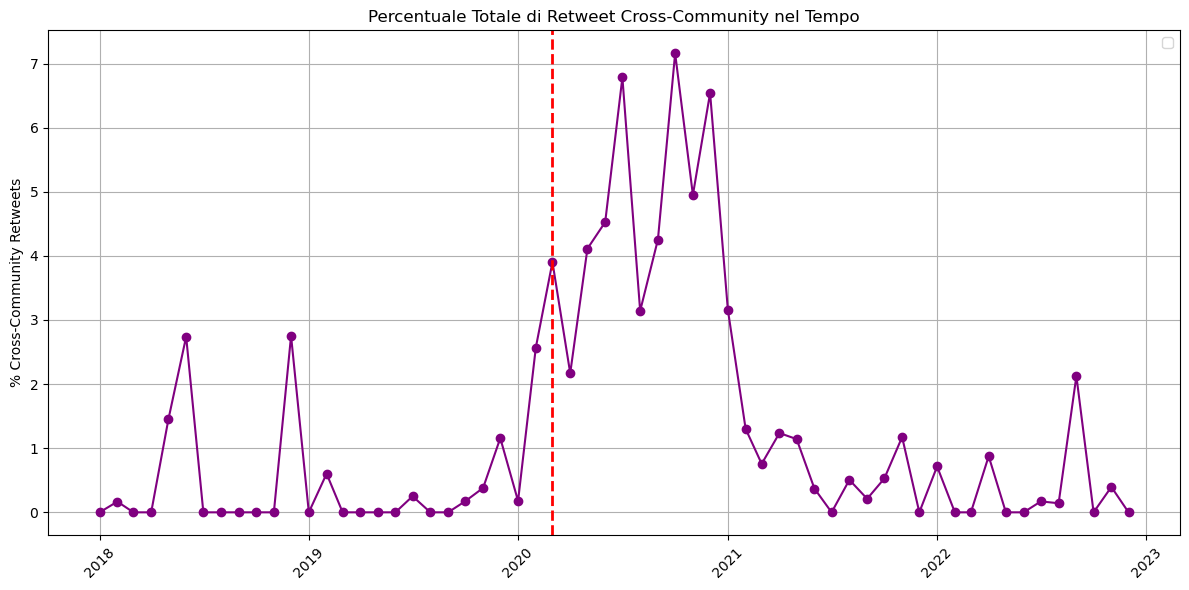

In [24]:
monthly_df = pd.DataFrame(monthly_ratios)
monthly_df['date'] = pd.to_datetime(monthly_df[['year', 'month']].assign(day=1))

# Plot
plt.figure(figsize=(12, 6))
plt.plot(monthly_df['date'], monthly_df['cross_ratio'], marker='o', color='purple')
plt.xticks(rotation=45)
plt.legend()
plt.ylabel("% Cross-Community Retweets")
plt.axvline(pd.Timestamp('2020-03-01'), color='red', linestyle='--', linewidth=2, label='Marzo 2020')
plt.title("Percentuale Totale di Retweet Cross-Community nel Tempo")
plt.grid(True)
plt.tight_layout()
plt.show()

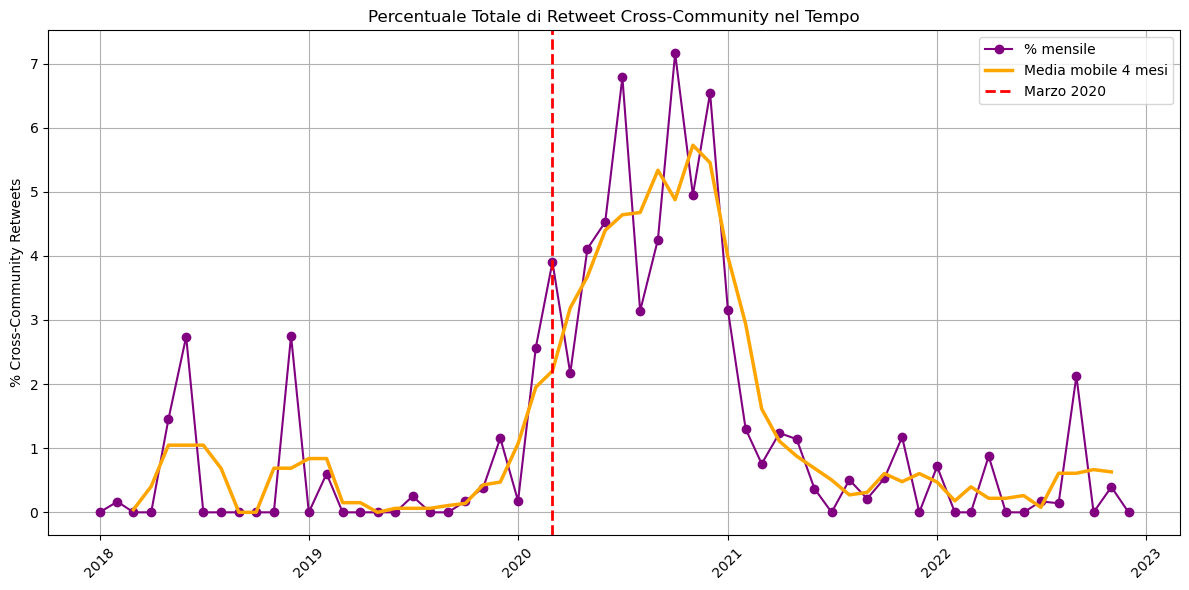

In [23]:
monthly_df = pd.DataFrame(monthly_ratios)
monthly_df['date'] = pd.to_datetime(monthly_df[['year', 'month']].assign(day=1))

# Calcola media mobile centrata (3 mesi)
monthly_df['cross_ratio_roll3'] = monthly_df['cross_ratio'].rolling(window=4, center=True).mean()

# Plot
plt.figure(figsize=(12, 6))
plt.plot(monthly_df['date'], monthly_df['cross_ratio'], marker='o', color='purple', label='% mensile')
plt.plot(monthly_df['date'], monthly_df['cross_ratio_roll3'], color='orange', linewidth=2.5, label='Media mobile 4 mesi')
plt.axvline(pd.Timestamp('2020-03-01'), color='red', linestyle='--', linewidth=2, label='Marzo 2020')
plt.xticks(rotation=45)
plt.ylabel("% Cross-Community Retweets")
plt.title("Percentuale Totale di Retweet Cross-Community nel Tempo")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# Voglio vedere quanto aumentano nel tempo i retweet di politici verso fonti non trustworthy

In [19]:
fonti_NT = df_leaders[df_leaders['pageCategory'] == 'NEWS_SITE'][df_leaders['Rating'] == 'N']['author_id'].unique().tolist()

C:\Users\alice\AppData\Local\Temp\ipykernel_12380\7845917.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  fonti_NT = df_leaders[df_leaders['pageCategory'] == 'NEWS_SITE'][df_leaders['Rating'] == 'N']['author_id'].unique().tolist()


In [20]:
#FILTRO PER I RETWEET FATTI DAI LEADER
df_NT_sources = df_retweets[df_retweets['retweeter_id'].isin(leaders)].copy()

# rinominno
originals = df_tweets[['id', 'author_id', 'created_at']].rename(
    columns={'id': 'post_id', 'author_id': 'original_author', 'created_at': 'tweet_date'}
)

# merge tramite post id per avere l'autore del tweet e l'ora del tweet
df_NT_sources  = (
    df_NT_sources 
    .merge(originals, on='post_id', how='inner')
)

#FILTRO anche l'original author che deve essere leader
df_NT_sources = df_NT_sources[df_NT_sources['original_author'].isin(fonti_NT)]


In [21]:
df_NT_sources['retweeter_id']

5361     1024976264
5362     1024976264
5363     1024976264
5364     1024976264
5365     1024976264
            ...    
32084     384927198
32138     384927198
32738     384927198
35500    1024976264
35506    1024976264
Name: retweeter_id, Length: 1236, dtype: object

In [22]:
dizionario_id = dict(zip(df_leaders['author_id'], df_leaders['author_screen_name']))

In [23]:
tweetano_fake_news = []
for id_ in df_NT_sources['retweeter_id']: 
    tweetano_fake_news.append(dizionario_id[id_])
from collections import Counter
conteggio = Counter(tweetano_fake_news)
print(conteggio)


Counter({'fratelliditalia': 471, 'si_sinistra': 408, 'nfratoianni': 314, 'legasalvini': 16, 'gparagone': 11, 'articolounomdp': 4, 'carlocalenda': 4, 'giorgiameloni': 2, 'ellyesse': 2, 'potere_alpopolo': 2, 'direzioneprc': 1, 'pdnetwork': 1})


# Dividiamo il dataset in prima e dopo covid e confrontiamo le partizioni

In [24]:
# Dividi il dataset
dataset_in_uso = df_leader_retweets
pre_covid = dataset_in_uso[dataset_in_uso['tweet_date'] < '2020-03-01']
post_covid = dataset_in_uso[dataset_in_uso['tweet_date'] >= '2020-03-01']

In [25]:
def build_graph(df):
    G = nx.Graph()
    edges = list(zip(df['retweeter_id'], df['original_author']))
    G.add_edges_from(edges)
    self_loops = list(nx.selfloop_edges(G))  # Trova i self loops
    G.remove_edges_from(self_loops)  # Rimuovili
    low_degree_nodes = [node for node, degree in G.degree() if degree < 3]
    G.remove_nodes_from(low_degree_nodes)
    return G

G_pre = build_graph(pre_covid)
G_post = build_graph(post_covid)

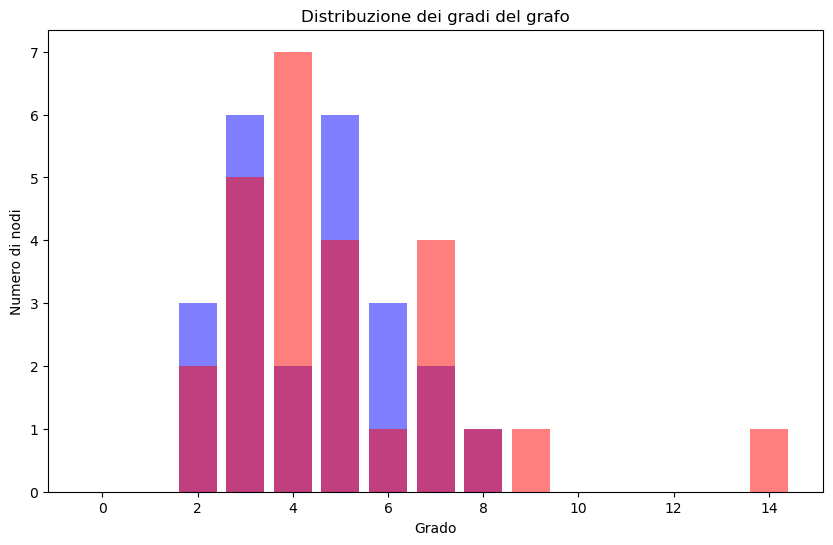

In [26]:

degree_freq_pre = nx.degree_histogram(G_pre)
degrees_pre = range(len(degree_freq_pre))

degree_freq_post = nx.degree_histogram(G_post)
degrees_post = range(len(degree_freq_post))
plt.figure(figsize=(10, 6))
plt.bar(degrees_pre, degree_freq_pre, width=0.80, color='blue', alpha = 0.5)
plt.bar(degrees_post, degree_freq_post, width=0.80, color='red', alpha = 0.5)

plt.title("Distribuzione dei gradi del grafo")
plt.xlabel("Grado")
plt.ylabel("Numero di nodi")
plt.show()

In [27]:
partition_pre = community_louvain.best_partition(G_pre)
partition_post = community_louvain.best_partition(G_post)
modularity_pre =  community_louvain.modularity(partition_pre, G_pre)
modularity_post =  community_louvain.modularity(partition_post, G_post)

In [28]:
print('MOD PRIMA = ' ,modularity_pre , 'MOD DOPO = ' , modularity_post)

MOD PRIMA =  0.5263360246059208 MOD DOPO =  0.4467401285583104


In [29]:
E_total = G_pre.number_of_edges()
E_cross = 0
for u, v in G_pre.edges():
    if partition_pre[u] != partition_pre[v]:
        E_cross += 1

bipartivity_multi = E_cross / E_total if E_total > 0 else 0
print(f"Bipartitività tra comunità: {bipartivity_multi:.3f}")

Bipartitività tra comunità: 0.137


In [30]:
E_total = G_post.number_of_edges()
E_cross = 0
for u, v in G_post.edges():
    if partition_post[u] != partition_post[v]:
        E_cross += 1

bipartivity_multi = E_cross / E_total if E_total > 0 else 0
print(f"Bipartitività tra comunità: {bipartivity_multi:.3f}")

Bipartitività tra comunità: 0.288


In [31]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

common_nodes = set(partition_pre.keys()).intersection(partition_post.keys())

labels_pre = [partition_pre[node] for node in common_nodes]
labels_post = [partition_post[node] for node in common_nodes]

# Confronto
ari = adjusted_rand_score(labels_pre, labels_post)
nmi = normalized_mutual_info_score(labels_pre, labels_post)

print(f"Adjusted Rand Index: {ari:.3f}")
print(f"Normalized Mutual Information: {nmi:.3f}")


Adjusted Rand Index: 0.223
Normalized Mutual Information: 0.455


C:\Users\alice\AppData\Local\Temp\ipykernel_12380\4275566925.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('viridis', max(partition.values()) + 1)


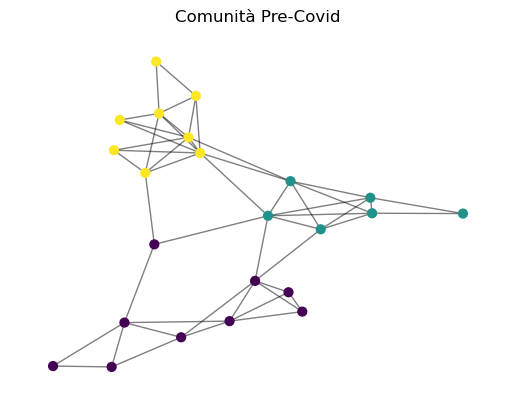

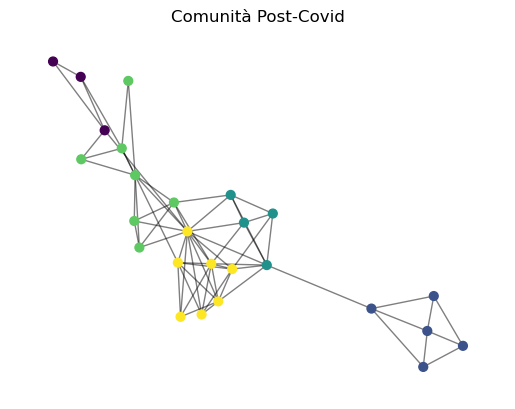

In [32]:
import matplotlib.pyplot as plt

def draw_partition(G, partition, title):
    pos = nx.spring_layout(G)
    self_loops = list(nx.selfloop_edges(G))  # Trova i self loops
    G.remove_edges_from(self_loops)  # Rimuovili
    
    cmap = plt.cm.get_cmap('viridis', max(partition.values()) + 1)
    nx.draw_networkx_nodes(G, pos, partition.keys(), node_size=40,
                           cmap=cmap, node_color=list(partition.values()))
    nx.draw_networkx_edges(G, pos, alpha=0.5)
    plt.title(title)
    plt.axis('off')
    plt.show()

draw_partition(G_pre, partition_pre, "Comunità Pre-Covid")
draw_partition(G_post, partition_post, "Comunità Post-Covid")


In [33]:
df = pre_covid.copy()
df['created_at'] = pd.to_datetime(df['tweet_date'])
df['month'] = df['created_at'].dt.to_period('M').dt.to_timestamp()
grouped = df.groupby([df['created_at'].dt.year, df['created_at'].dt.month])

monthly_ratios = []

for (year, month), group in grouped:
    total_retweets = len(group)
    group['retweeter_comm'] = group['retweeter_id'].map(partition_pre)
    group['original_comm'] = group['original_author'].map(partition_pre)
    cross_retweets = (group['retweeter_comm'] != group['original_comm']).sum()
    ratio = cross_retweets / total_retweets if total_retweets > 0 else 0

    monthly_ratios.append({
        'year': year,
        'month': month,
        'cross_ratio': ratio*100
    })

In [34]:
df = post_covid.copy()
df['created_at'] = pd.to_datetime(df['tweet_date'])
df['month'] = df['created_at'].dt.to_period('M').dt.to_timestamp()
grouped = df.groupby([df['created_at'].dt.year, df['created_at'].dt.month])

for (year, month), group in grouped:
    total_retweets = len(group)
    group['retweeter_comm'] = group['retweeter_id'].map(partition_post)
    group['original_comm'] = group['original_author'].map(partition_post)
    cross_retweets = (group['retweeter_comm'] != group['original_comm']).sum()
    ratio = cross_retweets / total_retweets if total_retweets > 0 else 0

    monthly_ratios.append({
        'year': year,
        'month': month,
        'cross_ratio': ratio*100
    })

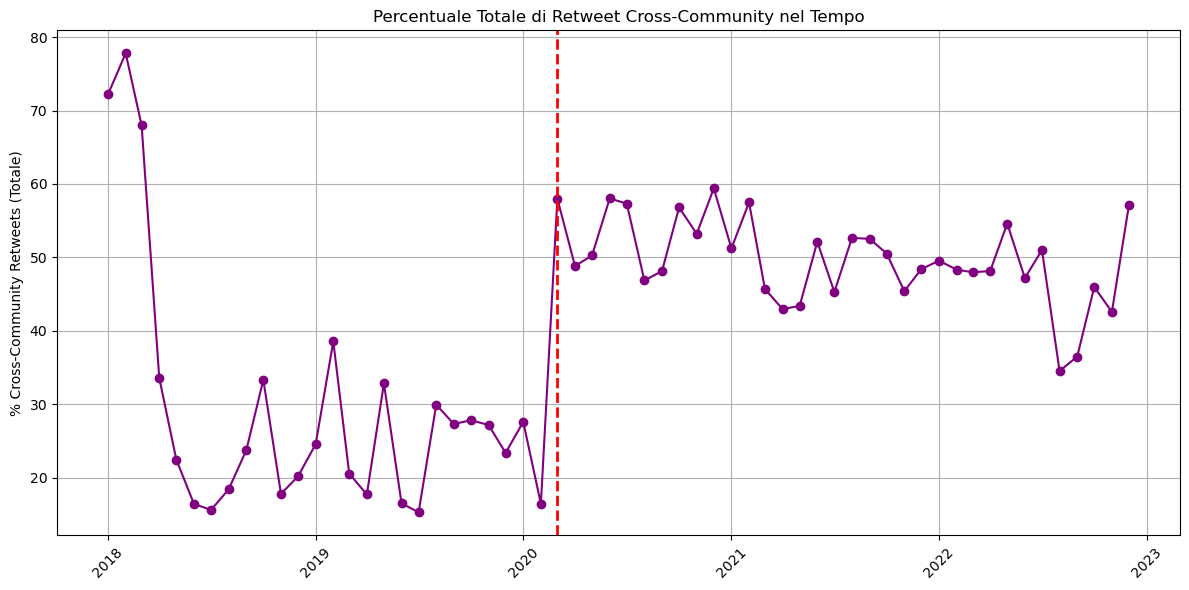

In [35]:
monthly_df = pd.DataFrame(monthly_ratios)
monthly_df['date'] = pd.to_datetime(monthly_df[['year', 'month']].assign(day=1))

# Plot
plt.figure(figsize=(12, 6))
plt.plot(monthly_df['date'], monthly_df['cross_ratio'], marker='o', color='purple')
plt.xticks(rotation=45)
plt.ylabel("% Cross-Community Retweets (Totale)")
plt.axvline(pd.Timestamp('2020-03-01'), color='red', linestyle='--', linewidth=2, label='Marzo 2020')

plt.title("Percentuale Totale di Retweet Cross-Community nel Tempo")
plt.grid(True)
plt.tight_layout()
plt.show()